# Customer Churn Prediction

# XGBoost Model

## Objective

Train and evaluate the XGBoost classifier for customer churn prediction using
the cleaned dataset. Performance will later be compared with CatBoost.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

import joblib

print("Libraries Loaded Successfully!")

Libraries Loaded Successfully!


In [2]:
df = pd.read_csv("../data/cleaned_telco.csv")

print(df.shape)

df.head()

(7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
if "customerID" in df.columns:
    df = df.drop(columns=["customerID"])

In [4]:
X = df.drop("Churn", axis=1)

y = df["Churn"].map({
    "No":0,
    "Yes":1
})

In [5]:
numerical_cols = X.select_dtypes(
    include=["int64","float64"]
).columns.tolist()

categorical_cols = X.select_dtypes(
    include=["object"]
).columns.tolist()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [7]:
encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)

X_train_cat = encoder.fit_transform(
    X_train[categorical_cols]
)

X_test_cat = encoder.transform(
    X_test[categorical_cols]
)

In [8]:
scaler = StandardScaler()

X_train_num = scaler.fit_transform(
    X_train[numerical_cols]
)

X_test_num = scaler.transform(
    X_test[numerical_cols]
)

In [9]:
X_train = np.hstack([
    X_train_num,
    X_train_cat
])

X_test = np.hstack([
    X_test_num,
    X_test_cat
])

print(X_train.shape)
print(X_test.shape)

(5634, 45)
(1409, 45)


In [23]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

In [24]:
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

In [25]:
param_grid = {

    "n_estimators": [100, 200, 300, 500],

    "max_depth": [3, 4, 5, 6, 8],

    "learning_rate": [0.01, 0.03, 0.05, 0.1],

    "subsample": [0.8, 0.9, 1.0],

    "colsample_bytree": [0.8, 0.9, 1.0],

    "gamma": [0, 0.1, 0.3, 0.5],

    "min_child_weight": [1, 3, 5, 7],

    "scale_pos_weight": [1.0, 2.77]

}

In [26]:
random_search = RandomizedSearchCV(

    estimator=xgb,

    param_distributions=param_grid,

    n_iter=30,

    scoring="roc_auc",

    cv=5,

    random_state=42,

    verbose=2,

    n_jobs=-1

)

In [27]:
random_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.8, 0.9, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichretu

In [28]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest ROC-AUC:")
print(random_search.best_score_)

Best Parameters:
{'subsample': 0.8, 'scale_pos_weight': 2.77, 'n_estimators': 500, 'min_child_weight': 7, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.8}

Best ROC-AUC:
0.8489770772240606


In [29]:
best_xgb = random_search.best_estimator_

In [30]:
y_pred = best_xgb.predict(X_test)

y_prob = best_xgb.predict_proba(X_test)[:, 1]

In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")

Accuracy : 0.7551
Precision: 0.5256
Recall   : 0.7968
F1 Score : 0.6334
ROC-AUC  : 0.8474


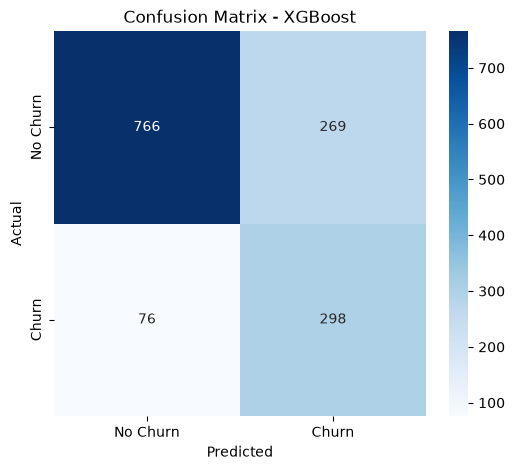

In [32]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Confusion Matrix - XGBoost")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.74      0.82      1035
           1       0.53      0.80      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.76      0.77      1409



In [34]:
feature_names = numerical_cols + encoder.get_feature_names_out(categorical_cols).tolist()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
36,Contract_Month-to-month,0.370587
16,InternetService_Fiber optic,0.068776
18,OnlineSecurity_No,0.061917
38,Contract_Two year,0.044291
27,TechSupport_No,0.035983
15,InternetService_DSL,0.024797
37,Contract_One year,0.022069
43,PaymentMethod_Electronic check,0.020635
35,StreamingMovies_Yes,0.020292
17,InternetService_No,0.020200


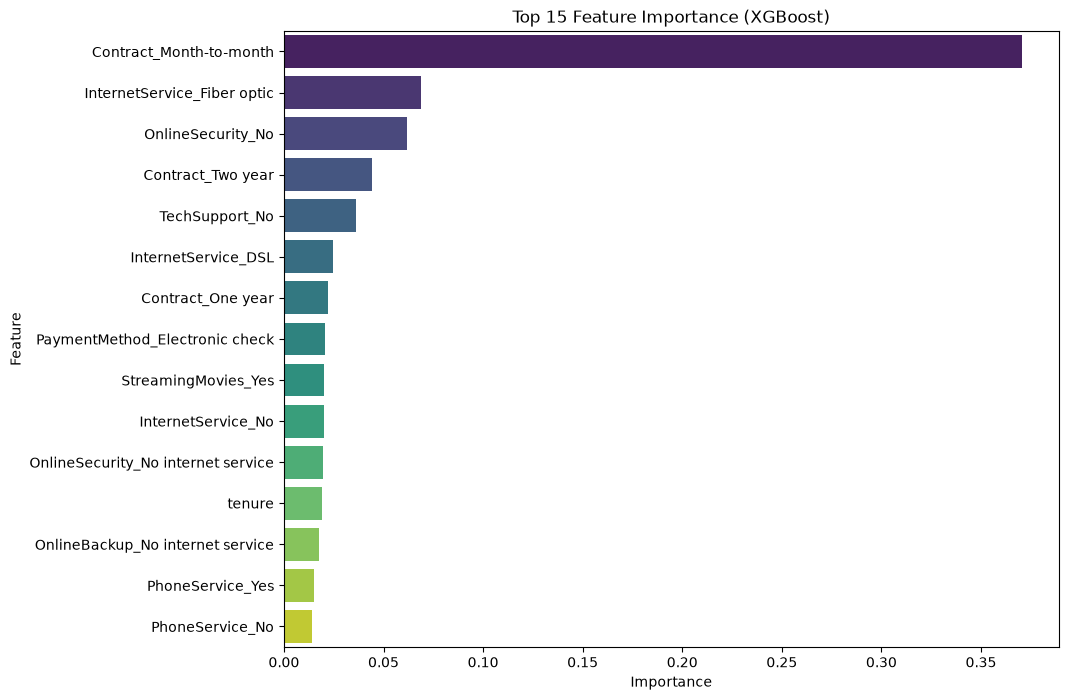

In [35]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 15 Feature Importance (XGBoost)")

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.show()

In [36]:
import joblib

joblib.dump(best_xgb, "../models/xgboost_model.pkl")

print("XGBoost model saved successfully!")

XGBoost model saved successfully!


In [37]:
joblib.dump(encoder, "../models/encoder.pkl")

joblib.dump(scaler, "../models/scaler.pkl")

print("Encoder and Scaler saved successfully!")

Encoder and Scaler saved successfully!
